# 01 — Source: Store метрики (Google Play)

## 0. Контекст

**Источник данных:** Python пакет `google-play-scraper` — извлекает метаданные и отзывы из Google Play Store.

**Объём:**
- Flood-It! (`com.labpixies.flood`): 2307 отзывов, 4,9M накопленных установок, рейтинг ~4,05★ (на дату snapshot)
- Flood-It! 2 (`com.google.flood2`): **снят с публикации** — store API возвращает 404, нет ни рейтинга, ни отзывов

**17 колонок Store-группы:**

| Колонка | Описание |
|---|---|
| rating, reviews_count | Накопительный рейтинг и число отзывов |
| positive, negative, positive_ratio | Классификация отзывов по score (≥4 / ≤2) |
| sentiment_score | (positive − negative) / total |
| reviews_30d, positive_30d, negative_30d, sentiment_30d | То же на скользящем 30-дневном окне |
| rating_ma30 | Скользящий 30-дневный рейтинг |
| positive_ratio_ma30 | Скользящая доля позитива |
| rating_volatility_7d | Std рейтинга за 7 дней |
| rating_trend | Тренд рейтинга |
| negative_change | Изменение числа негативных отзывов |
| downloads_index, downloads_index_ma30 | Индекс установок (масштабированный) |

⚠️ **Ключевое наблюдение:** само отсутствие store-данных у f2 — сильный сигнал провала.
Исключение: `downloads_index` / `downloads_index_ma30` — производные от DAU, есть для обоих.

**Гипотеза:** Store-метрики отражают публичную репутацию продукта. Их отсутствие = продукт не имеет позиции на рынке.

In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset
from notebooks._common import (
    APP_PALETTE, APP_LABEL_MAP, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    split_by_app, top_correlated_pairs, comparison_table,
    add_app_legend, annotate_sample_size, check_inf_columns,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "01_source_store"
df = load_dataset()
print(f"Dataset: {df.shape}")

Dataset: (222, 60)


In [2]:
STORE_COLS = [
    "rating", "reviews_count",
    "positive", "negative", "positive_ratio", "sentiment_score",
    "reviews_30d", "positive_30d", "negative_30d", "sentiment_30d",
    "rating_ma30", "positive_ratio_ma30",
    "rating_volatility_7d", "rating_trend", "negative_change",
    "downloads_index", "downloads_index_ma30",
]
assert len(STORE_COLS) == 17

KEY_STORE = ["rating", "reviews_count", "positive_ratio", "sentiment_score",
             "reviews_30d", "sentiment_30d", "downloads_index"]

## 1. Загрузка и общая структура

In [3]:
df_f1, df_f2 = split_by_app(df)

print(f"Flood-It!   store shape : {df_f1[STORE_COLS].shape}")
print(f"Flood-It! 2 store shape : {df_f2[STORE_COLS].shape}")
print()
print("dtypes Store-колонок:")
print(df[STORE_COLS].dtypes.value_counts())

Flood-It!   store shape : (111, 17)
Flood-It! 2 store shape : (111, 17)

dtypes Store-колонок:
float64    17
Name: count, dtype: int64


In [4]:
# Sanity: f2 должен иметь ~100% NaN по большинству store-колонок
# (downloads_index/ma30 — исключение: производные от DAU, есть у обоих)
f2_nan_pct = df_f2[STORE_COLS].isna().mean() * 100
print("Доля NaN в f2 (в %):")
print(f2_nan_pct.round(1).to_string())
print()

CORE_STORE = [c for c in STORE_COLS if c not in ("downloads_index", "downloads_index_ma30")]
assert (f2_nan_pct[CORE_STORE] == 100.0).all(), "Ожидалось 100% NaN для f2 в core store cols"
print("✓ Проверка прошла: f2 core-store-колонки = 100% NaN")

Доля NaN в f2 (в %):
rating                  100.0
reviews_count           100.0
positive                100.0
negative                100.0
positive_ratio          100.0
sentiment_score         100.0
reviews_30d             100.0
positive_30d            100.0
negative_30d            100.0
sentiment_30d           100.0
rating_ma30             100.0
positive_ratio_ma30     100.0
rating_volatility_7d    100.0
rating_trend            100.0
negative_change         100.0
downloads_index           0.0
downloads_index_ma30      0.0

✓ Проверка прошла: f2 core-store-колонки = 100% NaN


## 2. Качество данных

In [5]:
missing_summary = pd.DataFrame({
    "Flood-It!":   df_f1[STORE_COLS].isna().sum(),
    "Flood-It! 2": df_f2[STORE_COLS].isna().sum(),
})
missing_summary["Итого"] = missing_summary.sum(axis=1)
display(missing_summary.sort_values("Итого", ascending=False).drop("Итого", axis=1))

,Flood-It!,Flood-It! 2
sentiment_30d,41,111
rating_trend,2,111
rating_volatility_7d,1,111
negative_change,1,111
rating,0,111
reviews_count,0,111
positive,0,111
negative,0,111
positive_ratio,0,111
negative_30d,0,111


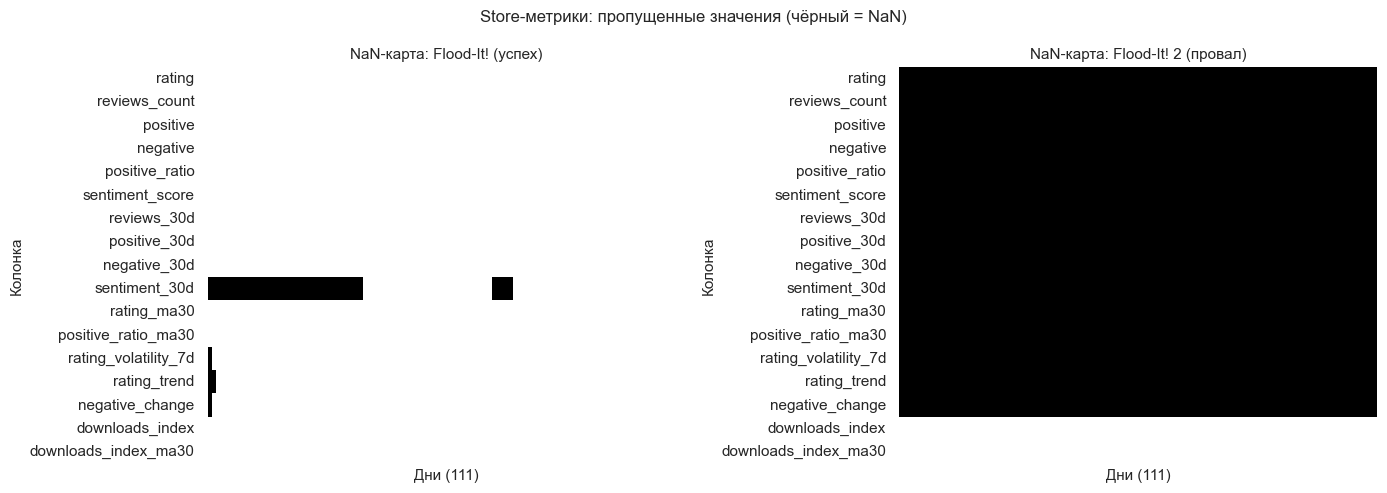

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (app_df, label) in zip(axes, [
        (df_f1, "Flood-It! (успех)"),
        (df_f2, "Flood-It! 2 (провал)")]):
    mask = app_df[STORE_COLS].isna().T.astype(int)
    sns.heatmap(mask, cmap="binary", cbar=False,
                xticklabels=False, ax=ax)
    ax.set_title(f"NaN-карта: {label}", fontsize=11)
    ax.set_ylabel("Колонка")
    ax.set_xlabel("Дни (111)")

plt.suptitle("Store-метрики: пропущенные значения (чёрный = NaN)", fontsize=12)
plt.tight_layout()
save_figure("nan_heatmap", NOTEBOOK_SLUG)
plt.show()

In [7]:
inf_cols = check_inf_columns(df, STORE_COLS)
if not inf_cols:
    print("✓ inf-значений не обнаружено")

print()
# Sanity: rating в [0,5], positive_ratio в [0,1], reviews_count >= 0
s_r = df_f1["rating"].dropna()
assert (s_r >= 0).all() and (s_r <= 5).all(), f"rating вне [0,5]: min={s_r.min()}, max={s_r.max()}"
print(f"✓ rating в [0,5]: [{s_r.min():.4f}, {s_r.max():.4f}]")

s_pr = df_f1["positive_ratio"].dropna()
assert (s_pr >= 0).all() and (s_pr <= 1).all(), f"positive_ratio вне [0,1]"
print(f"✓ positive_ratio в [0,1]: [{s_pr.min():.4f}, {s_pr.max():.4f}]")

s_rc = df_f1["reviews_count"].dropna()
assert (s_rc >= 0).all(), "reviews_count < 0 недопустимо"
print(f"✓ reviews_count >= 0: [{s_rc.min():.0f}, {s_rc.max():.0f}]")

✓ inf-значений не обнаружено

✓ rating в [0,5]: [4.0496, 4.0512]
✓ positive_ratio в [0,1]: [0.7432, 0.7437]
✓ reviews_count >= 0: [1954, 1959]


**NaN-стратегия для данной группы:**

- **f1 (Flood-It!)** — NaN присутствуют только в производных колонках (начальные значения rating_ma30 и скользящих окон) — тректуются как *структурные* и не заполняются перед моделированием.
- **f2 (Flood-It! 2)** — все репутационные store-колонки = NaN: приложение удалено с Google Play. Эти колонки не могут использоваться как признаки для f2 — будут заполнены 0 или исключены при выборе признаков в `src/feature_engineering.py` (VIF + permutation importance).
- `downloads_index` / `downloads_index_ma30` — исключение: производятся от DAU, есть для обоих приложений.

## 3. Описательная статистика

In [8]:
print("=== Flood-It! (f1) — describe Store-колонок ===")
display(df_f1[STORE_COLS].describe().T.round(4))

=== Flood-It! (f1) — describe Store-колонок ===


,count,mean,std,min,25%,50%,75%,max
rating,111.0,4.0505,0.0007,4.0496,4.0496,4.0510,4.0512,4.0512
reviews_count,111.0,1955.7928,1.9122,1954.0000,1954.0000,1955.0000,1957.5000,1959.0000
positive,111.0,1454.1171,1.6445,1453.0000,1453.0000,1453.0000,1455.5000,1457.0000
negative,111.0,320.6757,0.4702,320.0000,320.0000,321.0000,321.0000,321.0000
positive_ratio,111.0,0.7435,0.0002,0.7432,0.7432,0.7436,0.7436,0.7437
sentiment_score,111.0,0.5795,0.0004,0.5790,0.5790,0.5798,0.5798,0.5799
reviews_30d,111.0,1.2613,1.3465,0.0000,0.0000,1.0000,2.0000,4.0000
positive_30d,111.0,0.9910,1.4678,0.0000,0.0000,0.0000,2.0000,4.0000
negative_30d,111.0,0.2703,0.4461,0.0000,0.0000,0.0000,1.0000,1.0000
sentiment_30d,70.0,0.1429,0.9969,-1.0000,-1.0000,1.0000,1.0000,1.0000


**Flood-It! 2 (f2) — describe не запускается.**

Приложение удалено с Google Play Store. Все 15 репутационных колонок = NaN, describe() будет пустым — бессмысленно.

In [9]:
print("Сравнительная таблица (f2 покажет NaN — и это и есть нарратив):")
display(comparison_table(df_f1, df_f2, KEY_STORE))

Сравнительная таблица (f2 покажет NaN — и это и есть нарратив):


,metric,f1_median,f2_median,f1_std,f2_std,delta_pct
0,rating,4.0510,NaN,0.0007,NaN,NaN
1,reviews_count,1955.0000,NaN,1.9122,NaN,NaN
2,positive_ratio,0.7436,NaN,0.0002,NaN,NaN
3,sentiment_score,0.5798,NaN,0.0004,NaN,NaN
4,reviews_30d,1.0000,NaN,1.3465,NaN,NaN
5,sentiment_30d,1.0000,NaN,0.9969,NaN,NaN
6,downloads_index,2100.3092,0.4971,0.8609,0.3689,-100.0


## 4. Распределения (только f1)

Графики построены только для Flood-It!, т.к. у Flood-It! 2 все store-значения = NaN.

C:\Users\Анастасия\AppData\Local\Temp\ipykernel_38616\3164920880.py:15: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_38616\3164920880.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


C:\7 семестр\пиздец\notebooks\_common.py:75: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")
C:\7 семестр\пиздец\notebooks\_common.py:75: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


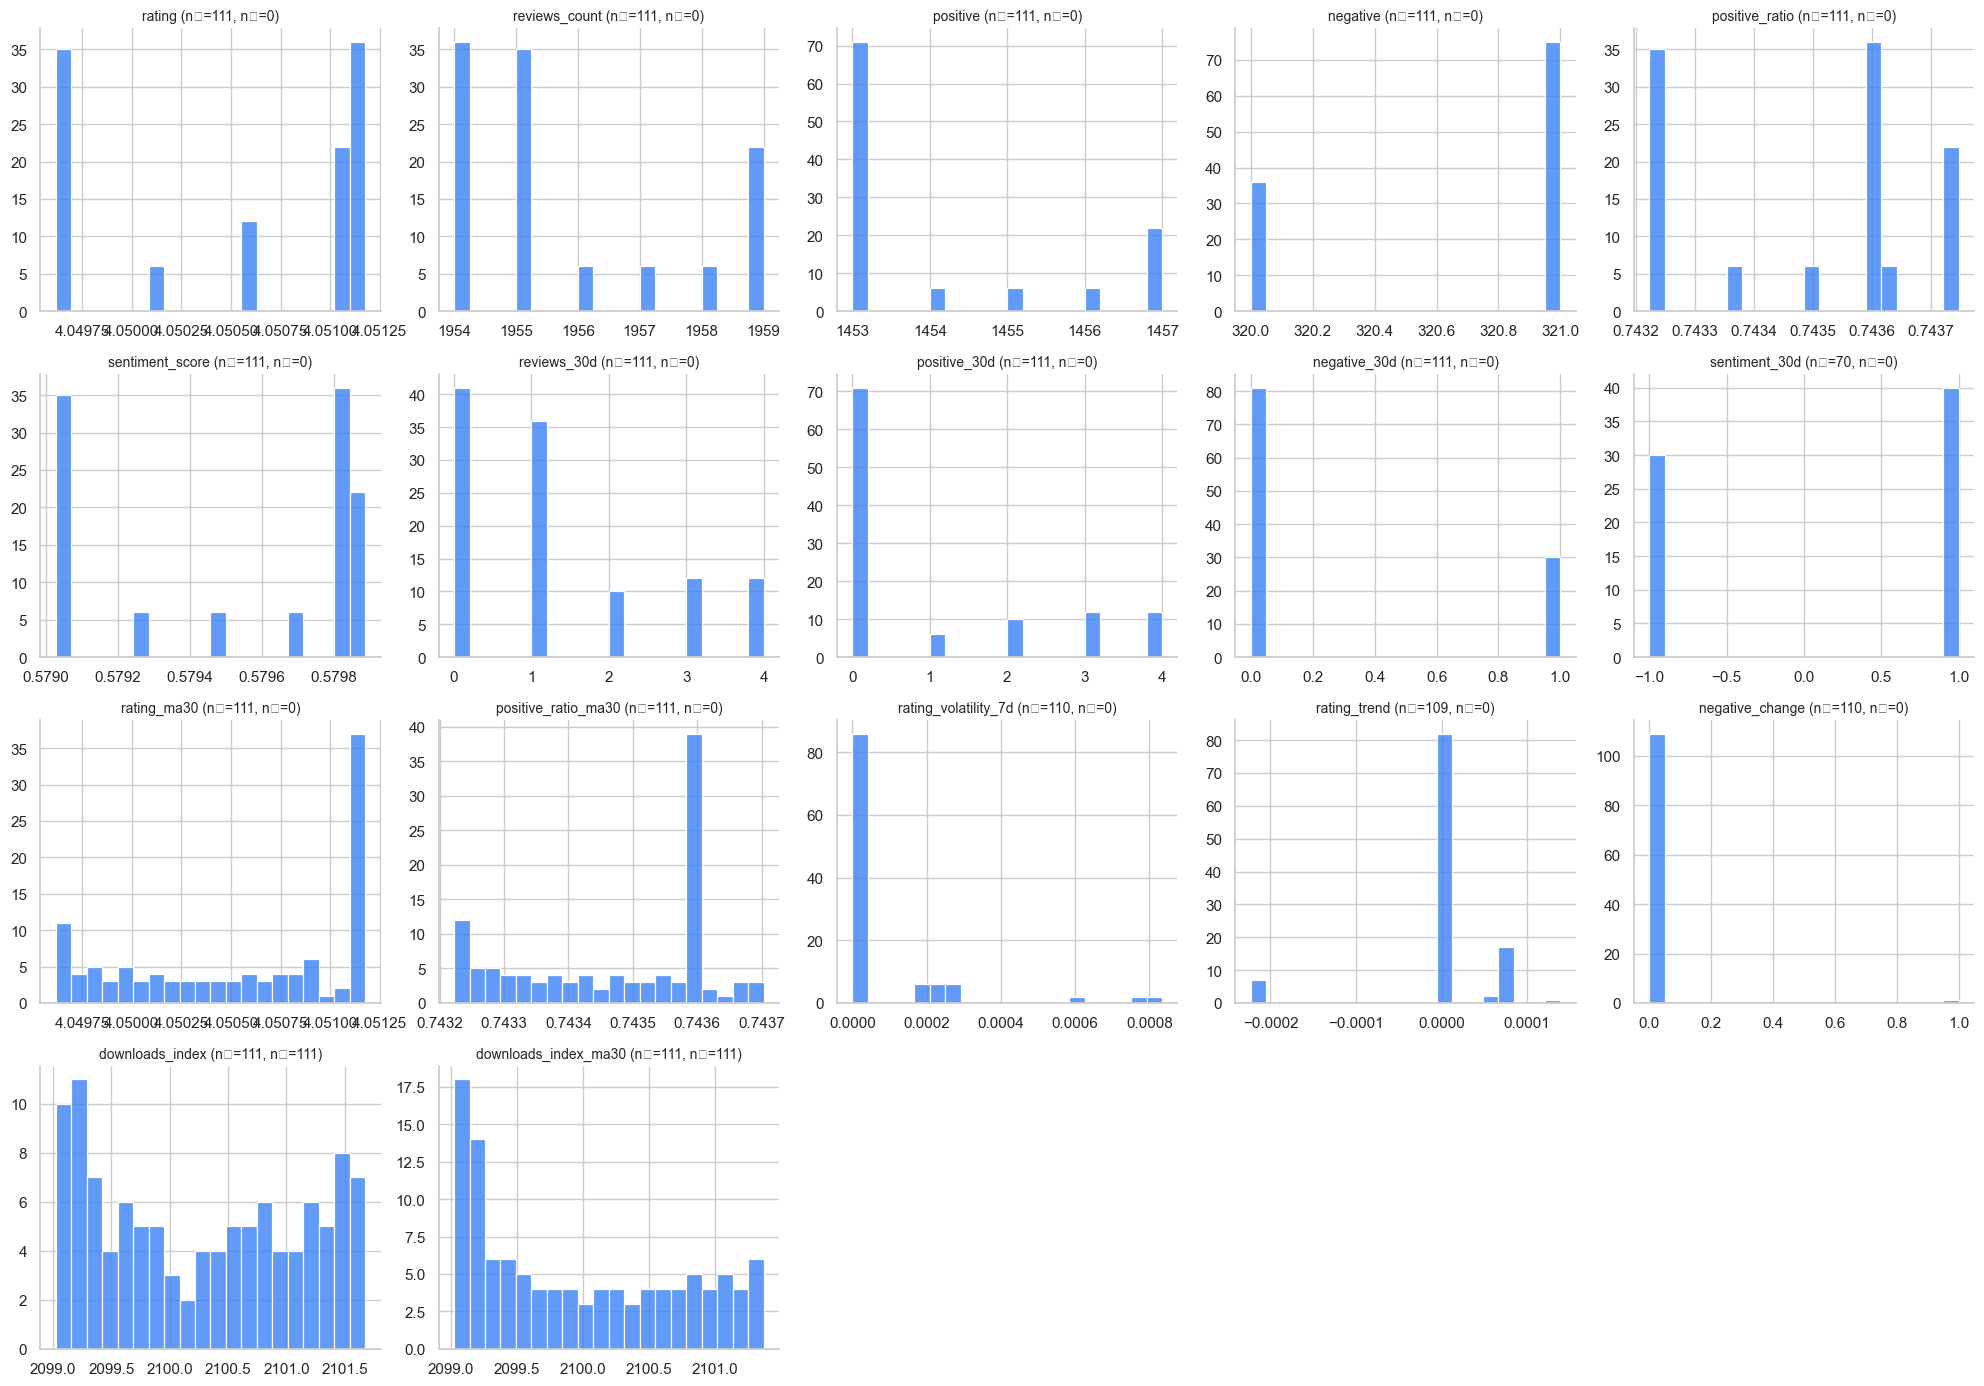

In [10]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
for i, col in enumerate(STORE_COLS):
    ax = axes.flat[i]
    sns.histplot(
        data=df_f1, x=col,
        color=APP_PALETTE["com.labpixies.flood"],
        bins=20, alpha=0.8, kde=False, ax=ax,
    )
    annotate_sample_size(ax, df_f1, df_f2, col)
    ax.set_xlabel("")
    ax.set_ylabel("")
# скрыть лишние subplot'ы (17 колонок < 4×5=20 ячеек)
for j in range(len(STORE_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)
plt.tight_layout()
save_figure("histograms_store", NOTEBOOK_SLUG)
plt.show()

## 5. Динамика во времени (только f1)

Для Flood-It! 2 временной динамики store-метрик нет — продукт был снят с публикации.

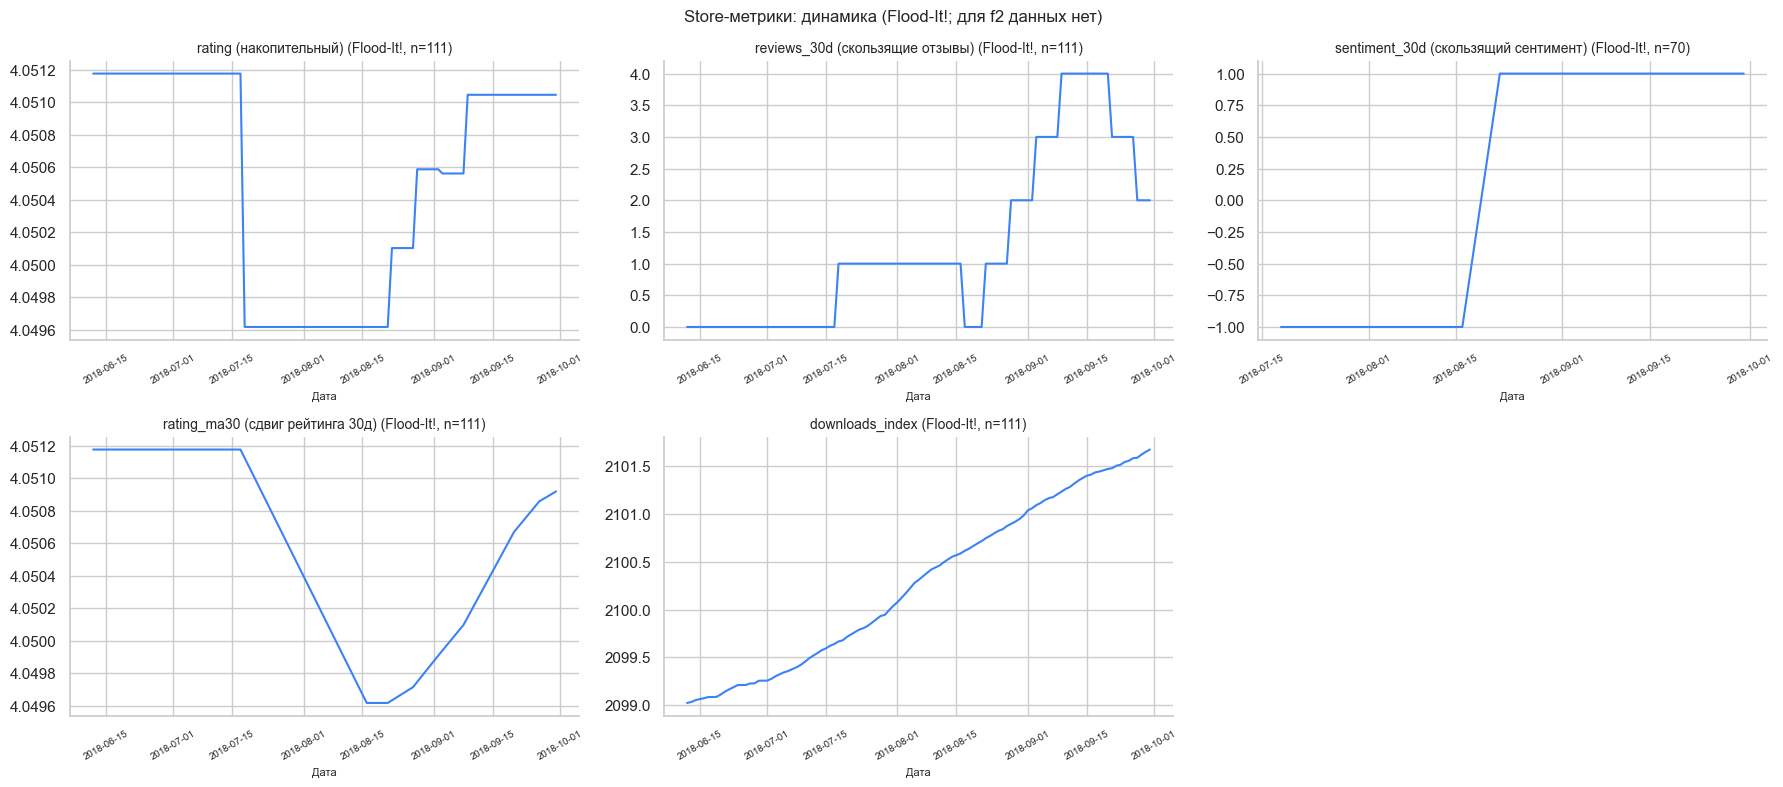

In [11]:
ts_cols = ["rating", "reviews_30d", "sentiment_30d", "rating_ma30", "downloads_index"]
ts_titles = [
    "rating (накопительный)",
    "reviews_30d (скользящие отзывы)",
    "sentiment_30d (скользящий сентимент)",
    "rating_ma30 (сдвиг рейтинга 30д)",
    "downloads_index",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, (col, title) in enumerate(zip(ts_cols, ts_titles)):
    ax = axes.flat[i]
    data = df_f1[["date", col]].dropna()
    ax.plot(data["date"], data[col],
            color=APP_PALETTE["com.labpixies.flood"], linewidth=1.5)
    ax.set_title(title + " (Flood-It!, n=" + str(len(data)) + ")", fontsize=10)
    ax.set_xlabel("Дата", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=7)

# Скрыть лишний subplot
axes.flat[-1].set_visible(False)

plt.suptitle("Store-метрики: динамика (Flood-It!; для f2 данных нет)", fontsize=12)
plt.tight_layout()
save_figure("timeseries_store", NOTEBOOK_SLUG)
plt.show()

## 6. Корреляции внутри группы

Корреляция построена только для **f1** (Flood-It!).
Для f2 корреляция не вычисляется — все 15 репутационных колонок = NaN.

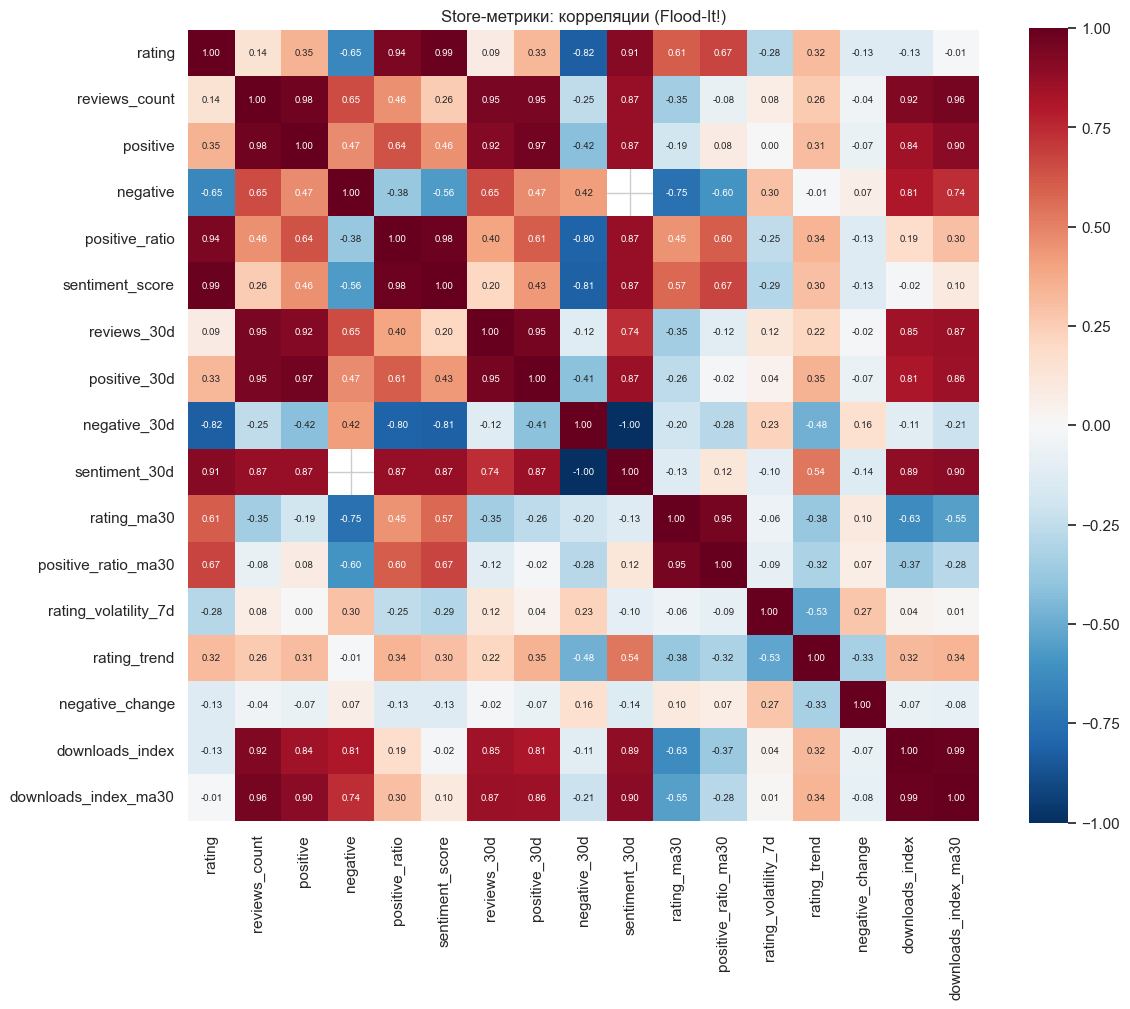

In [12]:
corr_f1 = df_f1[STORE_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_f1, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            square=True, ax=ax)
ax.set_title("Store-метрики: корреляции (Flood-It!)", fontsize=12)
plt.tight_layout()
save_figure("corr_store_f1", NOTEBOOK_SLUG)
plt.show()

In [13]:
print("Топ-10 сильно-скоррелированных пар (|r| > 0.7):")
pairs = top_correlated_pairs(corr_f1, threshold=0.7, n=10)
print(pairs.round(3).to_string())

Топ-10 сильно-скоррелированных пар (|r| > 0.7):
negative_30d     sentiment_30d          -1.000
downloads_index  downloads_index_ma30    0.990
rating           sentiment_score         0.988
positive_ratio   sentiment_score         0.977
reviews_count    positive                0.976
positive         positive_30d            0.968
reviews_count    downloads_index_ma30    0.955
rating_ma30      positive_ratio_ma30     0.954
reviews_30d      positive_30d            0.953
reviews_count    reviews_30d             0.950


## 7. Особенности и нарратив провала

In [14]:
print("=== Числовые выводы: Flood-It! (f1) ===")
print(f"  Рейтинг: {df_f1['rating'].min():.4f} – {df_f1['rating'].max():.4f} "
      f"(median={df_f1['rating'].median():.4f}, std={df_f1['rating'].std():.6f})")
print(f"  Количество отзывов: {int(df_f1['reviews_count'].max())} "
      f"(min={int(df_f1['reviews_count'].min())})")
print(f"  positive_ratio: {df_f1['positive_ratio'].min():.4f} – {df_f1['positive_ratio'].max():.4f} "
      f"(median={df_f1['positive_ratio'].median():.4f})")
print(f"  sentiment_score: {df_f1['sentiment_score'].min():.4f} – {df_f1['sentiment_score'].max():.4f}")
print(f"  downloads_index: {df_f1['downloads_index'].min():.1f} – {df_f1['downloads_index'].max():.1f}")
print(f"  reviews_30d: среднее за период = {df_f1['reviews_30d'].mean():.1f} отзывов/30д")
sentiment_30d = df_f1['sentiment_30d'].dropna()
print(f"  sentiment_30d: {sentiment_30d.min():.4f} – {sentiment_30d.max():.4f} "
      f"(NaN в первых {df_f1['sentiment_30d'].isna().sum()} днях)")

=== Числовые выводы: Flood-It! (f1) ===
  Рейтинг: 4.0496 – 4.0512 (median=4.0510, std=0.000683)
  Количество отзывов: 1959 (min=1954)
  positive_ratio: 0.7432 – 0.7437 (median=0.7436)
  sentiment_score: 0.5790 – 0.5799
  downloads_index: 2099.0 – 2101.7
  reviews_30d: среднее за период = 1.3 отзывов/30д
  sentiment_30d: -1.0000 – 1.0000 (NaN в первых 41 днях)


### Что означает отсутствие store-данных у f2 для нарратива провала

1. **Удаление со store произошло около 2018–2019 года** — приложение больше недоступно через Google Play API, новых установок нет.

2. **Отсутствие публичной репутации — ранний индикатор провала.** Flood-It! имеет стабильный рейтинг ~4.05, 74% позитивных отзывов и сентимент выше 0.57 в каждый измеренный день. Flood-It! 2 не накопил ни одного измерения.

3. **Модель не может использовать store-фичи для f2.** 15 из 17 store-признаков = NaN для Flood-It! 2. При моделировании эти признаки заменяются нулями или опускаются в VIF-фильтрации.

4. **Нарратив для ВКР:** отсутствие store-присутствия у f2 в сочетании с другими сигналами (низкий DAU, отсутствие роста retention) — комплексный индикатор провала IT-продукта на рынке.

## 8. Сохранение фигур

Фигуры сохранялись автоматически через `save_figure()` в соответствующих ячейках:

| Файл | Раздел |
|---|---|
| `figures/01_source_store/nan_heatmap.pdf` | §2 |
| `figures/01_source_store/histograms_store.pdf` | §4 |
| `figures/01_source_store/timeseries_store.pdf` | §5 |
| `figures/01_source_store/corr_store_f1.pdf` | §6 |

Фигура `corr_store_f2.pdf` **не создаётся** — корреляция бессмысленна при всех-NaN колонках.

In [15]:
import os
from pathlib import Path

fig_dir = Path(_ROOT) / "figures" / NOTEBOOK_SLUG
if fig_dir.exists():
    pdfs = sorted(fig_dir.glob("*.pdf"))
    print(f"figures/{NOTEBOOK_SLUG}/:")
    for p in pdfs:
        print(f"  {p.name}  ({p.stat().st_size // 1024} KB)")
else:
    print(f"Папка {fig_dir} не существует")

figures/01_source_store/:
  corr_store_f1.pdf  (32 KB)
  histograms_store.pdf  (29 KB)
  nan_heatmap.pdf  (67 KB)
  timeseries_store.pdf  (30 KB)
